# Assignment 4: Regularization
### Dishitha Dhakshin (qxk8wp)

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty discourages large coefficients. If parameters get too big, the model is likely overfitting noise. The penalty forces the model to stay simpler by shrinking coefficients, improving generalization to new data.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization increases bias (by restricting flexibility) but reduces variance (by preventing overfitting). By tuning the penalty strength, we can find a balance where the model is not too complex (low variance) but still captures patterns (reasonable bias).

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Ridge (L2) shrinks coefficients toward zero but rarely makes them exactly zero.
LASSO (L1) can shrink some coefficients exactly to zero, performing feature selection. So, LASSO gives sparse models, while Ridge keeps all variables but with smaller weights.

4. How do we typically scale variables for use in regularized regression? Why?

We standardize variables (mean 0, variance 1). This ensures all features are penalized equally—otherwise, variables with larger scales would dominate the penalty and distort results.

5. How is the penalty $\alpha$ typically selected?

α is typically chosen using cross-validation. We try different values and pick the one that minimizes validation error.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No. We evaluate performance using only the prediction error (MSE), not the penalty. The penalty is just a tool to fit the model, but we care about how well it predicts unseen data.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 126 (delta 0), reused 0 (delta 0), pack-reused 124 (from 2)
Receiving objects: 100% (126/126), 12.31 MiB | 8.86 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./undergrad_ml_assignments/data/cars_hw.csv')

df = df.drop(columns=['Unnamed: 0'])

df['Age'] = 2024 - df['Make_Year']

X = df[['Mileage_Run', 'Age']]
y = df['Price']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [4]:
#Q2.2

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_scaled, y)

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

for name, coef in zip(feature_names, model.coef_):
    print(name, coef)

Mileage_Run 668616.517209674
Age -184194.14613723248
Mileage_Run^2 -149467.87417613144
Mileage_Run Age -1251592.3408260453
Age^2 215639.8787572434
Mileage_Run^3 -65144.89659917474
Mileage_Run^2 Age 283339.15222242544
Mileage_Run Age^2 528082.863474972
Age^3 -138937.02579369987


The interaction between Mileage_Run and Age is negative. This means that when both mileage and age increase together, the price decreases more than expected from their individual effects. In simple terms, older cars with higher mileage lose value faster.

In [5]:
#Q2.3

from sklearn.linear_model import LassoCV
import numpy as np

alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)

lasso.fit(X_scaled, y)

print("Best alpha:", lasso.alpha_)

Best alpha: 483.2930238571752


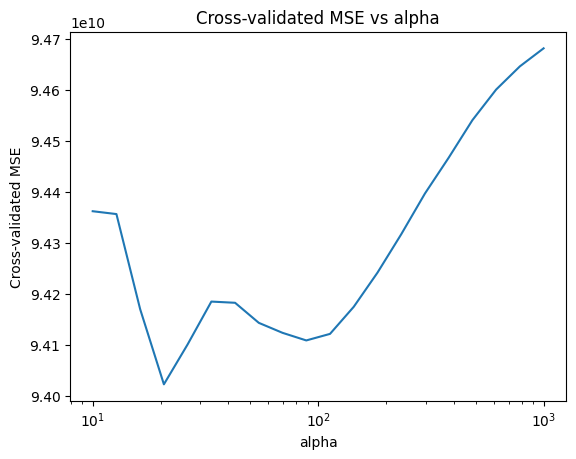

In [6]:
#Q2.4

import matplotlib.pyplot as plt

mse_mean = lasso.mse_path_.mean(axis=1)

plt.plot(alphas, mse_mean)
plt.xscale('log')

plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('Cross-validated MSE vs alpha')

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.408e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.686e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.202e+11, tolerance: 1.316e

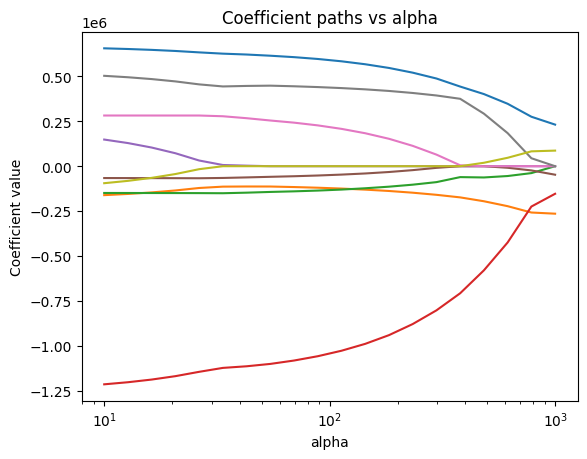

In [7]:
#Q2.5

from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt

coefs = []

for a in alphas:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_scaled, y)
    coefs.append(lasso_temp.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('Coefficient paths vs alpha')

plt.show()

In [8]:
#Q2.6

coefs = lasso.coef_

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

selected = feature_names[coefs != 0]

prop_zero = np.mean(coefs == 0)

print("Selected features:", selected)
print("Proportion set to zero:", prop_zero)

Selected features: ['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Mileage_Run Age^2'
 'Age^3']
Proportion set to zero: 0.3333333333333333


The selected features are Mileage_Run, Age, Mileage_Run², Mileage_Run × Age, Mileage_Run × Age², and Age³. About 33% of the features are set to zero, meaning LASSO removes less important variables and simplifies the model.

In [9]:
for name, lin, las in zip(feature_names, model.coef_, lasso.coef_):
    print(f"{name}: Linear={lin:.2f}, Lasso={las:.2f}")

Mileage_Run: Linear=668616.52, Lasso=401025.26
Age: Linear=-184194.15, Lasso=-194803.12
Mileage_Run^2: Linear=-149467.87, Lasso=-62539.29
Mileage_Run Age: Linear=-1251592.34, Lasso=-578788.66
Age^2: Linear=215639.88, Lasso=-0.00
Mileage_Run^3: Linear=-65144.90, Lasso=-0.00
Mileage_Run^2 Age: Linear=283339.15, Lasso=0.00
Mileage_Run Age^2: Linear=528082.86, Lasso=292015.03
Age^3: Linear=-138937.03, Lasso=19133.91


Compared to linear regression, the LASSO coefficients are generally smaller because of the penalty. Some coefficients are also set exactly to zero, such as Mileage_Run³ and Mileage_Run² × Age, which means those features are removed from the model.

No coefficients increase in magnitude from linear regression to LASSO. Most coefficients keep the same sign, although a few may change slightly due to relationships between variables.

Overall, LASSO creates a simpler model by shrinking coefficients and removing less important features.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [ ]:
df = pd.read_csv("./data/heart_failure_clinical_records_dataset.csv")
df.head()

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

Link to answers: https://drive.google.com/file/d/1EW0Bn2nroOounm8FlEtxhTuKfjOQQzE0/view?usp=sharing